# DSCI 303 - Homework 05

### Sean Graham

**Due: Sunday, June 7, 2020, 11:59 pm**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Part 1: Working with 2D Arrays

In [2]:
np.random.seed(1)
Z = np.random.uniform(low = 0, high = 10, size = (5,8))
Z = np.round(Z, 2)
print(Z)

[[4.17 7.2  0.   3.02 1.47 0.92 1.86 3.46]
 [3.97 5.39 4.19 6.85 2.04 8.78 0.27 6.7 ]
 [4.17 5.59 1.4  1.98 8.01 9.68 3.13 6.92]
 [8.76 8.95 0.85 0.39 1.7  8.78 0.98 4.21]
 [9.58 5.33 6.92 3.16 6.87 8.35 0.18 7.5 ]]


In [3]:
print('Row 3:    ' + str(Z[3,:]))
print('Column 6: ' + str(Z[:,6]))

Row 3:    [8.76 8.95 0.85 0.39 1.7  8.78 0.98 4.21]
Column 6: [1.86 0.27 3.13 0.98 0.18]


In [4]:
print('Row Sums:    ' + str(np.sum(Z, axis=1)))
print('Column Sums: ' + str(np.sum(Z, axis=0)))
print('Array Sum:   ' + str(np.sum(Z)))

Row Sums:    [22.1  38.19 40.88 34.62 47.89]
Column Sums: [30.65 32.46 13.36 15.4  20.09 36.51  6.42 28.79]
Array Sum:   183.68


## Part 2: Reshaping and Stacking Arrays

In [5]:
np.random.seed(167)
x1 = np.random.normal(loc = 50, scale = 10, size = 1000)
x2 = np.random.normal(loc = 20, scale = 5, size = 1000)
x3 = np.random.normal(loc = 100, scale = 30, size = 1000)
x4 = np.random.normal(loc = 10, scale = 2, size = 1000)

cx1 = x1.reshape(1000,1)
cx2 = x2.reshape(1000,1)
cx3 = x3.reshape(1000,1)
cx4 = x4.reshape(1000,1)

X = np.hstack([cx1, cx2, cx3, cx4])
X = np.round(X, 2)
print(X.shape)

(1000, 4)


In [6]:
print(X[:6,:])

[[ 37.08  16.71 138.06   8.89]
 [ 41.32  19.91  99.61   9.86]
 [ 63.15  14.43  70.08  11.6 ]
 [ 50.03  12.71  95.05   8.47]
 [ 55.05  24.4   62.16   9.49]
 [ 59.24  25.68  64.57  12.84]]


## Part 3: Standardization

In [7]:
X_column_means = np.mean(X, axis = 0)
X_column_stdevs = np.std(X, axis = 0)

print('Column means:               ' + str(np.round(X_column_means, 2)))
print('Column standard deviations: ' + str(np.round(X_column_stdevs, 2)))

Column means:               [50.21 19.86 99.84 10.06]
Column standard deviations: [ 9.69  5.08 30.88  2.03]


In [8]:
W = (X - X_column_means) / X_column_stdevs

W_column_means = np.mean(W, axis = 0)
W_column_stdevs = np.std(W, axis = 0)

print('Column means:               ' + str(np.round(W_column_means, 2)))
print('Column standard deviations: ' + str(np.round(W_column_stdevs, 2)))

Column means:               [ 0. -0. -0. -0.]
Column standard deviations: [1. 1. 1. 1.]


## Part 4: Load Auto MPG Dataset

In [9]:
auto = pd.read_csv('auto_mpg.txt', sep='\t')
auto.head(10)

,mpg,cyl,wt,region,model
0,27.2,4,3190,eur,peugeot 504
1,32.8,4,1985,asia,mazda glc deluxe
2,18.1,6,3410,usa,amc concord d/l
3,17.5,8,4080,usa,dodge magnum xe
4,25.4,5,3530,eur,mercedes benz 300d
5,31.0,4,1773,asia,toyota corolla 1200
6,27.4,4,2670,usa,amc spirit dl
7,39.1,4,1755,asia,toyota starlet
8,34.3,4,2188,eur,audi 4000
9,30.0,4,2155,usa,buick opel isuzu deluxe


In [10]:
print(auto.shape)

(398, 5)


In [11]:
auto_means = np.mean(auto, axis = 0)
print(auto_means)

mpg      23.514573
cyl       5.454774
wt     2970.424623
dtype: float64


## Part 5: Regional Counts and Means

In [12]:
regions = np.unique(auto.loc[:,'region'])
print(regions)

['asia' 'eur' 'usa']


In [13]:
sel_asia = auto.loc[:,'region'] == 'asia'
asia_auto = auto.loc[sel_asia,:]

sel_eur = auto.loc[:,'region'] == 'eur'
eur_auto = auto.loc[sel_eur,:]

sel_usa = auto.loc[:,'region'] == 'usa'
usa_auto = auto.loc[sel_usa,:]

len_asia = len(asia_auto)
len_eur = len(eur_auto)
len_usa = len(usa_auto)

print('Number of cars manufactured in Asia:   ' + str(len_asia))
print('Number of cars manufactured in Europe: ' + str(len_eur))
print('Number of cars manufactured in USA:    ' + str(len_usa))

Number of cars manufactured in Asia:   79
Number of cars manufactured in Europe: 70
Number of cars manufactured in USA:    249


In [14]:
asia_means = [np.mean(asia_auto.loc[:,'mpg']), np.mean(asia_auto.loc[:,'cyl']), np.mean(asia_auto.loc[:,'wt'])]
eur_means = [np.mean(eur_auto.loc[:,'mpg']), np.mean(eur_auto.loc[:,'cyl']), np.mean(eur_auto.loc[:,'wt'])]
usa_means = [np.mean(usa_auto.loc[:,'mpg']), np.mean(usa_auto.loc[:,'cyl']), np.mean(usa_auto.loc[:,'wt'])]

mean_df_info = [list(asia_means),
                list(eur_means),
                list(usa_means)]
mean_df = pd.DataFrame(data = mean_df_info,
                      index = list(regions),
                      columns = ['mpg','cyl','wt'])
mean_df

,mpg,cyl,wt
asia,30.450633,4.101266,2221.227848
eur,27.891429,4.157143,2423.300000
usa,20.083534,6.248996,3361.931727


## Part 6: Average Weight and MPG by Region

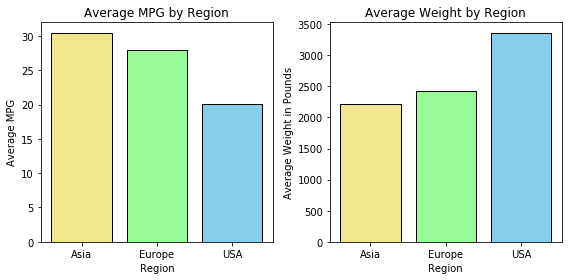

In [15]:
colors1 = ['khaki', 'palegreen', 'skyblue']

index = ['Asia','Europe','USA']
mpg = mean_df.mpg.to_list()
wt = mean_df.wt.to_list()

plt.figure(figsize = [8,4])
plt.subplot(1,2,1)
plt.bar(x = index, height = mpg, color = colors1, edgecolor = "black")
plt.xlabel('Region')
plt.ylabel('Average MPG')
plt.title('Average MPG by Region')

plt.subplot(1,2,2)
plt.bar(x = index, height = wt, color = colors1, edgecolor = "black")
plt.xlabel('Region')
plt.ylabel('Average Weight in Pounds')
plt.title('Average Weight by Region')

plt.tight_layout()
plt.show()

## Part 7: Relationship between Weight and Miles Per Gallon

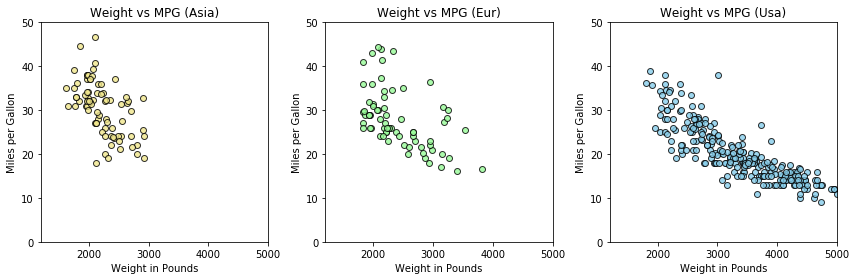

In [16]:
region = auto['region']
wt = auto['wt']
mpg = auto['mpg']

plt.figure(figsize = [12,4])
for i in range(0, len(regions)):
    sel = (region == regions[i])
    plt.subplot(1,3,i+1)
    plt.scatter(x = wt[sel], y = mpg[sel], edgecolor = 'black', color = colors1[i], alpha = 0.8)
    
    plt.xlim([1200,5000])
    plt.ylim([0,50])
    plt.xlabel('Weight in Pounds')
    plt.ylabel('Miles per Gallon')
    plt.title('Weight vs MPG (' + regions[i].title() + ')')
    
plt.tight_layout()
plt.show()

## Part 8: Cylinder Distribution by Region

In [17]:
cyl_values = np.unique(auto.loc[:,'cyl'])
print(cyl_values)

[3 4 5 6 8]


In [18]:
cyl_counts_by_region = pd.crosstab(auto.loc[:,'cyl'], auto.loc[:,'region'])
cyl_counts_by_region

region,asia,eur,usa
cyl,,,
3,4,0,0
4,69,63,72
5,0,3,0
6,6,4,74
8,0,0,103


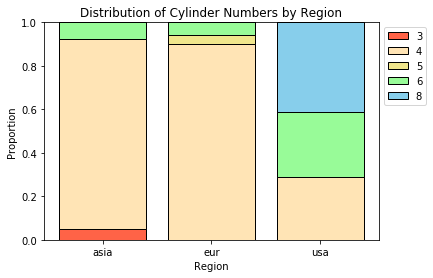

In [19]:
cyl_props_by_region = cyl_counts_by_region / cyl_counts_by_region.sum(axis=0)

bar_bottoms = np.cumsum(cyl_props_by_region) - cyl_props_by_region

colors2 = ['tomato','moccasin','khaki', 'palegreen', 'skyblue']

plt.figure(figsize = [6,4])

for i in range(5):
    plt.bar(regions, cyl_props_by_region.iloc[i,:], label = cyl_values[i], bottom = bar_bottoms.iloc[i,:],
    color = colors2[i], edgecolor='black')

plt.xlabel('Region')
plt.ylabel('Proportion')
plt.title('Distribution of Cylinder Numbers by Region')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()